# **Chest X-Ray Images**

# Import Libraries & Setup

In [1]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torchvision.transforms as transforms
from collections import Counter
from tqdm import tqdm

# =========================
# CONFIG
# =========================
IMG_SIZE = 150
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.0005

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True

DATASET_ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

# LOAD DATA

In [2]:
def build_df(root):
    data = []
    for label_name in CLASS_NAMES:
        label = CLASS_NAMES.index(label_name)
        folder = os.path.join(root, label_name)

        for img in os.listdir(folder):
            data.append({"path": os.path.join(folder, img), "label": label})
    return pd.DataFrame(data)

train_df = build_df(os.path.join(DATASET_ROOT, "train"))
test_df = build_df(os.path.join(DATASET_ROOT, "test"))

train_df, val_df = train_test_split(
     train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)

# TRANSFORMER

In [3]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])


# Data Class & DataLoader

In [4]:
class ChestXRayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row["path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.float32)
        return image, label

# =========================
# DATALOADER
# =========================
train_loader = DataLoader(ChestXRayDataset(train_df, train_transform),
                         batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=True)

val_loader = DataLoader(ChestXRayDataset(val_df, val_transform),
                       batch_size=BATCH_SIZE, num_workers=2)

test_loader = DataLoader(ChestXRayDataset(test_df, val_transform),
                        batch_size=BATCH_SIZE, num_workers=2)

# MODEL & CLASS IMBALANCE

In [5]:
class EdgeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)   # No sigmoid
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = EdgeCNN().to(device)

# =========================
# LOSS + OPTIMIZER
# =========================
counts = Counter(train_df["label"])
total = sum(counts.values())
pos_weight = torch.tensor(total / counts[1]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================
# AMP
# =========================
scaler = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))


# Training Function

In [6]:
def train():
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        loop = tqdm(train_loader)

        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


# EVALUATION

In [7]:
def evaluate(loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            y_pred.extend(preds.flatten())
            y_true.extend(labels.numpy())

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title("Confusion Matrix")
    plt.show()


# RUN 

100%|██████████| 70/70 [01:25<00:00,  1.22s/it, loss=0.357]


Epoch 1, Loss: 0.3560


100%|██████████| 70/70 [00:50<00:00,  1.38it/s, loss=0.128]


Epoch 2, Loss: 0.1932


100%|██████████| 70/70 [00:50<00:00,  1.40it/s, loss=0.00874]


...

100%|██████████| 70/70 [00:50<00:00,  1.40it/s, loss=0.0452]


Epoch 9, Loss: 0.1106


100%|██████████| 70/70 [00:49<00:00,  1.40it/s, loss=0.072]

Epoch 10, Loss: 0.0918

Validation Results:


Accuracy: 0.9323116219667944
Precision: 0.9962476547842402
Recall: 0.9123711340206185
F1: 0.9524663677130045


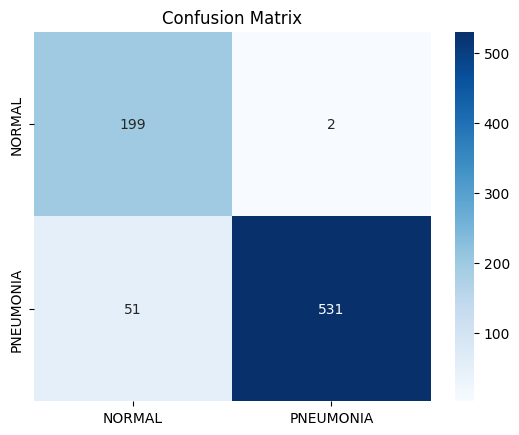


Test Results:
Accuracy: 0.875
Precision: 0.8561643835616438
Recall: 0.9615384615384616
F1: 0.9057971014492754


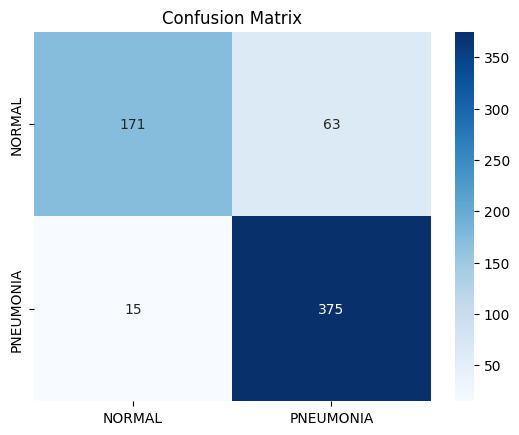

In [8]:
train()

print("\nValidation Results:")
evaluate(val_loader)

print("\nTest Results:")
evaluate(test_loader)

# =========================
#  SAVE MODEL
# =========================
torch.save(model.state_dict(), "edge_ai_model.pth")


# EDGE AI EXPORT (TorchScript)

In [9]:
def export_model_for_edge(model):
    model.eval()
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

    traced = torch.jit.trace(model, dummy_input)
    traced.save("edge_ai_model_optimized.pt")

    size = os.path.getsize("edge_ai_model_optimized.pt") / (1024*1024)
    print(f"\nEdge Model Size: {size:.2f} MB")

export_model_for_edge(model)


Edge Model Size: 3.54 MB


# QUANTIZATION

In [10]:
quantized_model = torch.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)

torch.save(quantized_model.state_dict(), "edge_ai_model_quantized.pth")
print("Quantized model saved!")

Quantized model saved!


/tmp/ipykernel_22/695247875.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(
